# SupportSense — TensorFlow Neural Text Classifier

This notebook develops a TensorFlow/Keras neural classifier for the
BANKING77 customer-support intent classification problem.

The architecture is designed to be broadly comparable with the PyTorch
embedding classifier developed previously.

The workflow includes:

1. Loading BANKING77
2. Creating training and validation datasets
3. Building a training-only vocabulary
4. Encoding and padding text
5. Creating TensorFlow datasets
6. Building an embedding-based Keras model
7. Training and validation
8. Controlled hyperparameter experiments
9. Final training
10. Official test evaluation
11. Error analysis
12. Comparison with sklearn and PyTorch

In [1]:
# Imports
from pathlib import Path
from collections import Counter

import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

I0000 00:00:1791401209.127697  183267 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791401209.128432  183267 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791401209.183137  183267 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791401210.549355  183267 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(
    "TensorFlow version:",
    tf.__version__
)

print(
    "Available GPUs:",
    tf.config.list_physical_devices(
        "GPU"
    )
)

TensorFlow version: 2.22.0-rc0
Available GPUs: []


E0000 00:00:1791401264.878073  183267 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



In [3]:
# Load the reusable project code
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(
        str(PROJECT_ROOT)
    )

In [4]:
from src.data.loader import (
    load_banking77_data,
)

In [5]:
# Load the data
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

train_df, test_df = (
    load_banking77_data(
        DATA_DIR
    )
)

print(
    "Original training:",
    train_df.shape
)

print(
    "Official test:",
    test_df.shape
)

Original training: (10003, 2)
Official test: (3080, 2)


In [6]:
# Recreating the development split

train_data, val_data = (
    train_test_split(
        train_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=train_df[
            "category"
        ],
    )
)

train_data = (
    train_data
    .reset_index(drop=True)
)

val_data = (
    val_data
    .reset_index(drop=True)
)

In [7]:
# Checking
print(
    "Training:",
    len(train_data)
)

print(
    "Validation:",
    len(val_data)
)

print(
    "Official test:",
    len(test_df)
)

Training: 8002
Validation: 2001
Official test: 3080


In [8]:
# Reusing the same simple tokenizer
# To keep the PyTorch/TensorFlow comparison fair, the same tokenisation strategy is used

def tokenize(text):
    """
    Convert text into lowercase
    whitespace-separated tokens.
    """

    return str(text).lower().split()

In [9]:
# Test
print(
    tokenize(
        "My card has not arrived"
    )
)

['my', 'card', 'has', 'not', 'arrived']


In [10]:
# Building the training-only vocabulary
token_counts = Counter()

for text in train_data["text"]:
    token_counts.update(
        tokenize(text)
    )

In [11]:
MIN_FREQUENCY = 2

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token, count in (
    token_counts.items()
):
    if count >= MIN_FREQUENCY:
        vocab[token] = len(vocab)

In [12]:
# Checking
VOCAB_SIZE = len(vocab)

print(
    "Vocabulary size:",
    VOCAB_SIZE
)

Vocabulary size: 2189


In [13]:
# Use the same maximum length
MAX_LENGTH = 44

In [14]:
# Building the label mapping
intent_names = sorted(
    train_data[
        "category"
    ].unique()
)

intent_to_id = {
    intent: index
    for index, intent
    in enumerate(intent_names)
}

id_to_intent = {
    index: intent
    for intent, index
    in intent_to_id.items()
}

NUM_CLASSES = len(
    intent_to_id
)

print(
    "Number of classes:",
    NUM_CLASSES
)

Number of classes: 77


In [15]:
# Encode text
def encode_text(
    text,
    vocab,
    max_length,
):
    tokens = tokenize(
        text
    )

    token_ids = [
        vocab.get(
            token,
            vocab[UNK_TOKEN],
        )
        for token in tokens
    ]

    token_ids = token_ids[
        :max_length
    ]

    padding_needed = (
        max_length
        - len(token_ids)
    )

    token_ids = token_ids + (
        [vocab[PAD_TOKEN]]
        * padding_needed
    )

    return token_ids

In [16]:
# Testing
encoded_example = encode_text(
    "my card has not arrived",
    vocab,
    MAX_LENGTH,
)

print(encoded_example)

print(
    "Length:",
    len(encoded_example)
)

[11, 39, 305, 152, 564, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 44


In [17]:
# Creating a function that converts a DataFrame
def dataframe_to_arrays(
    dataframe,
    vocab,
    intent_to_id,
    max_length,
):
    encoded_texts = [
        encode_text(
            text,
            vocab,
            max_length,
        )
        for text
        in dataframe["text"]
    ]

    encoded_labels = [
        intent_to_id[
            intent
        ]
        for intent
        in dataframe["category"]
    ]

    X = np.array(
        encoded_texts,
        dtype=np.int32,
    )

    y = np.array(
        encoded_labels,
        dtype=np.int32,
    )

    return X, y

In [18]:
# Converting training and validation data
X_train, y_train = (
    dataframe_to_arrays(
        train_data,
        vocab,
        intent_to_id,
        MAX_LENGTH,
    )
)

X_val, y_val = (
    dataframe_to_arrays(
        val_data,
        vocab,
        intent_to_id,
        MAX_LENGTH,
    )
)

In [19]:
# Checking
print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

X_train: (8002, 44)
y_train: (8002,)
X_val: (2001, 44)
y_val: (2001,)


In [20]:
# Converting a small sample
example_tensor = (
    tf.convert_to_tensor(
        X_train[:5]
    )
)

print(example_tensor)

print(
    example_tensor.shape
)

tf.Tensor(
[[ 2  3  4  5  6  7  8  9 10 11 12  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [13 14 15 16 17 18 19 20 21  7 22 23 24 25 26 27 28 29 30 31 32 33 34  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [35 36 20 37 30 38 39  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 2  4 20 40 41 42  7 43 41 44  9 45  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [13 46 20 47  7 48 49 50  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]], shape=(5, 44), dtype=int32)
(5, 44)


In [21]:
# Create tf.data.Dataset
# This is the rough TensorFlow equivalent of the PyTorch Dataset + DataLoader pipeline.
# Using the same batch size: 64

BATCH_SIZE = 64

In [22]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train,
            y_train,
        )
    )
)

In [23]:
# Validation
val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val,
            y_val,
        )
    )
)

## Shuffle and batch

In [24]:
# Training
train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=len(
            X_train
        ),
        seed=RANDOM_STATE,
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


In [25]:
# Validation
val_dataset = (
    val_dataset
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

In [26]:
# Inspecting one TensorFlow batch
for batch_inputs, batch_labels in (
    train_dataset.take(1)
):
    print(
        "Inputs:",
        batch_inputs.shape
    )

    print(
        "Labels:",
        batch_labels.shape
    )

Inputs: (64, 44)
Labels: (64,)


## Build the TensorFlow neural network
# Architecture
Input
 ↓
Embedding(mask_zero=True)
 ↓
GlobalAveragePooling1D
 ↓
Dropout
 ↓
Dense(77)
 ↓
Logits


NOTE: This is intentionally similar to the PyTorch network

In [27]:
# Define the starting configuration
# Using the same initial configuration originally used for PyTorch
EMBEDDING_DIM = 128
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001

In [ ]:
# Creating a reusable model builder
def build_tensorflow_model(
    vocab_size,
    embedding_dim,
    num_classes,
    max_length,
    dropout_rate,
    learning_rate,
):
    inputs = tf.keras.Input(
        shape=(max_length,),
        dtype=tf.int32,
        name="input_ids",
    )

    x = tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True,
        name="embedding",
    )(inputs)

    x = (
        tf.keras.layers
        .GlobalAveragePooling1D(
            name="mean_pooling"
        )(x)
    )

    x = tf.keras.layers.Dropout(
        dropout_rate,
        name="dropout",
    )(x)

    logits = tf.keras.layers.Dense(
        num_classes,
        name="classifier",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=logits,
        name="supportsense_tensorflow",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=(
            tf.keras.losses
            .SparseCategoricalCrossentropy(
                from_logits=True
            )
        ),
        metrics=[
            "accuracy"
        ],
    )

    return model

In [29]:
# Building the model
tf.random.set_seed(
    RANDOM_STATE
)

model = build_tensorflow_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_classes=NUM_CLASSES,
    max_length=MAX_LENGTH,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

In [30]:
model.summary()

Model: "supportsense_tensorflow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 44, 128)        │       280,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mean_pooling                    │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 77)             │         9,933 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,125 (1.11 MB)

 Trainable params: 290,125 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Counting parameters
tensorflow_parameter_count = (
    model.count_params()
)

print(
    f"TensorFlow parameters: "
    f"{tensorflow_parameter_count:,}"
)

TensorFlow parameters: 290,125


In [32]:
# Perform one forward pass
# Using the batch you inspected earlier:

logits = model(
    batch_inputs,
    training=False,
)

print(
    "Logits shape:",
    logits.shape
)

Logits shape: (64, 77)


In [33]:
# Converting logits to predictions
predicted_class_ids = (
    tf.argmax(
        logits,
        axis=1,
    )
)

print(
    predicted_class_ids[:10]
)

tf.Tensor([72 50 52 49 70 35 72 24 20 61], shape=(10,), dtype=int64)


In [34]:
first_prediction = int(
    predicted_class_ids[0]
)

print(
    id_to_intent[
        first_prediction
    ]
)

virtual_card_not_working


## Adding Macro F1 monitoring
Keras' simple built-in accuracy metric isn't enough for this project.
Validation Macro F1 will be calculated after each epoch with a callback.

In [35]:
class ValidationMacroF1(
    tf.keras.callbacks.Callback
):
    def __init__(
        self,
        validation_dataset,
    ):
        super().__init__()

        self.validation_dataset = (
            validation_dataset
        )

        self.f1_scores = []

    def on_epoch_end(
        self,
        epoch,
        logs=None,
    ):
        all_labels = []
        all_predictions = []

        for inputs, labels in (
            self.validation_dataset
        ):
            logits = self.model(
                inputs,
                training=False,
            )

            predictions = (
                tf.argmax(
                    logits,
                    axis=1,
                )
                .numpy()
            )

            all_predictions.extend(
                predictions.tolist()
            )

            all_labels.extend(
                labels.numpy().tolist()
            )

        macro_f1 = f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        )

        self.f1_scores.append(
            macro_f1
        )

        if logs is not None:
            logs[
                "val_macro_f1"
            ] = macro_f1

        print(
            f" - val_macro_f1: "
            f"{macro_f1:.4f}"
        )

In [36]:
# Create the callback
macro_f1_callback = (
    ValidationMacroF1(
        validation_dataset=(
            val_dataset
        )
    )
)

In [37]:
# Training the first TensorFlow model
NUM_EPOCHS = 20

In [38]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=NUM_EPOCHS,
    callbacks=[
        macro_f1_callback
    ],
)

Epoch 1/20


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2923 - loss: 4.2777 - val_macro_f1: 0.4159
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2923 - loss: 4.2777 - val_accuracy: 0.4653 - val_loss: 4.1701 - val_macro_f1: 0.4159
Epoch 2/20
118/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4861 - loss: 3.9562 - val_macro_f1: 0.4514
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4864 - loss: 3.9404 - val_accuracy: 0.5142 - val_loss: 3.6539 - val_macro_f1: 0.4514
Epoch 3/20
119/126 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5544 - loss: 3.2789 - val_macro_f1: 0.5128
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5556 - loss: 3.2620 - val_accuracy: 0.5677 - val_loss: 2.9229 - val_macro_f1: 0.5128
Epoch 4/20
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6192 - loss: 2.5611 - val_macro_f1: 0.5829
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6218 - loss: 2.5503 - val_accuracy: 0.6377 - val_loss: 2.3173 - val_macro_f1: 0.5829
Epoch 5/20
11

In [39]:
# Building a history DataFrame
tensorflow_history = (
    pd.DataFrame(
        history.history
    )
)

tensorflow_history[
    "epoch"
] = range(
    1,
    len(tensorflow_history) + 1
)

tensorflow_history

,accuracy,loss,val_accuracy,val_loss,val_macro_f1,epoch
0,0.292302,4.277673,0.465267,4.170108,0.415912,1
1,0.486378,3.940417,0.514243,3.653893,0.451444,2
2,0.555611,3.262015,0.567716,2.922860,0.512840,3
3,0.621845,2.550282,0.637681,2.317318,0.582878,4
4,0.699450,2.010082,0.682659,1.889204,0.645788,5
5,0.748313,1.633772,0.722139,1.591706,0.695493,6
6,0.792927,1.355485,0.751624,1.376309,0.734697,7
7,0.822294,1.157673,0.769115,1.217601,0.755214,8
8,0.841540,1.008490,0.784608,1.096723,0.774481,9
9,0.856661,0.887297,0.799600,1.000381,0.790839,10


In [40]:
# Cheacking
tensorflow_history.columns.tolist()

['accuracy', 'loss', 'val_accuracy', 'val_loss', 'val_macro_f1', 'epoch']

In [41]:
# Finding the best 
best_tf_index = (
    tensorflow_history[
        "val_macro_f1"
    ].idxmax()
)

best_tf_row = (
    tensorflow_history.loc[
        best_tf_index
    ]
)

In [42]:
print(
    "Best epoch:",
    int(
        best_tf_row[
            "epoch"
        ]
    )
)

print(
    f"Best validation accuracy: "
    f"{best_tf_row['val_accuracy']:.4f}"
)

print(
    f"Best validation Macro F1: "
    f"{best_tf_row['val_macro_f1']:.4f}"
)

Best epoch: 20
Best validation accuracy: 0.8556
Best validation Macro F1: 0.8554


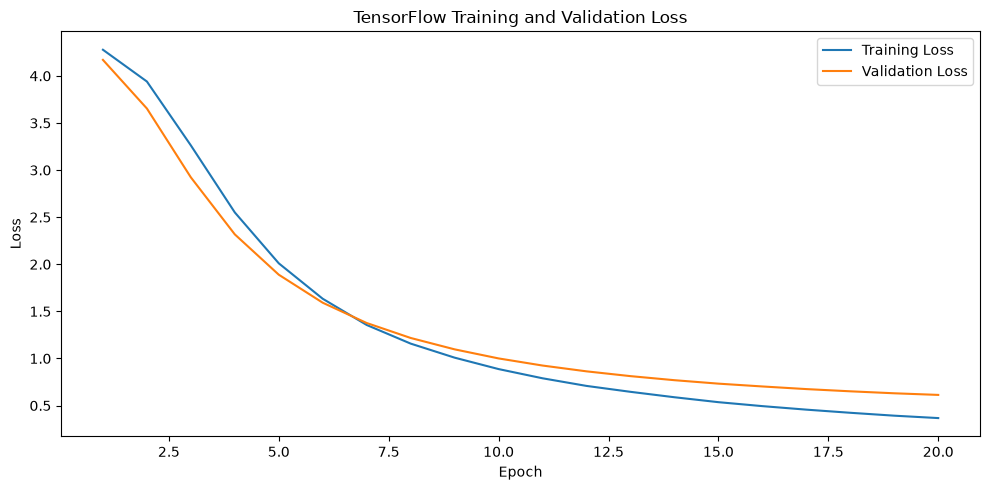

In [43]:
# Plot loss
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    tensorflow_history[
        "epoch"
    ],
    tensorflow_history[
        "loss"
    ],
    label="Training Loss",
)

plt.plot(
    tensorflow_history[
        "epoch"
    ],
    tensorflow_history[
        "val_loss"
    ],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "TensorFlow Training and Validation Loss"
)
plt.legend()
plt.tight_layout()
plt.show()

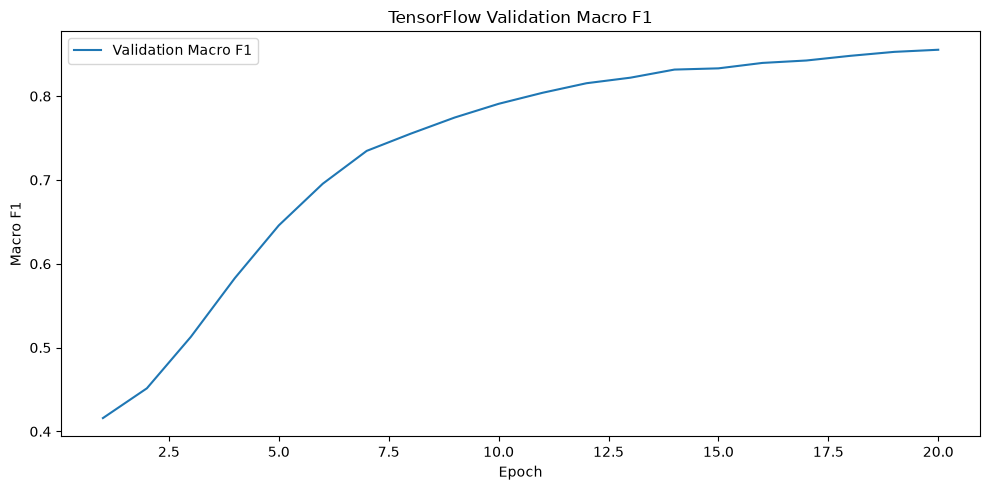

In [44]:
# Plot validation Macro F1
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    tensorflow_history[
        "epoch"
    ],
    tensorflow_history[
        "val_macro_f1"
    ],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title(
    "TensorFlow Validation Macro F1"
)
plt.legend()
plt.tight_layout()
plt.show()

# Controlled TensorFlow tuning
# The same six configurations as in PyTorch will be used so the comparison can be fair

Embedding dimensions:
64
128
256

Learning rates:
0.0005
0.001



# Keep fixed
Dropout = 0.3
Batch size = 64
MAX_LENGTH = same as PyTorch (44)
Tokenisation = same
Vocabulary rules = same

In [45]:
# Experimenting settings
TF_EXPERIMENT_EPOCHS = 12

tf_embedding_options = [
    64,
    128,
    256,
]

tf_learning_rate_options = [
    0.0005,
    0.001,
]

In [46]:
# Creating the TensorFlow experiment function
def run_tensorflow_experiment(
    embedding_dim,
    learning_rate,
    num_epochs,
):
    tf.keras.backend.clear_session()

    tf.random.set_seed(
        RANDOM_STATE
    )

    experiment_model = (
        build_tensorflow_model(
            vocab_size=VOCAB_SIZE,
            embedding_dim=embedding_dim,
            num_classes=NUM_CLASSES,
            max_length=MAX_LENGTH,
            dropout_rate=DROPOUT_RATE,
            learning_rate=learning_rate,
        )
    )

    f1_callback = (
        ValidationMacroF1(
            validation_dataset=(
                val_dataset
            )
        )
    )

    experiment_history = (
        experiment_model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=num_epochs,
            callbacks=[
                f1_callback
            ],
            verbose=0,
        )
    )

    history_df = pd.DataFrame(
        experiment_history.history
    )

    history_df[
        "val_macro_f1"
    ] = f1_callback.f1_scores

    best_index = (
        history_df[
            "val_macro_f1"
        ].idxmax()
    )

    best_epoch = (
        best_index + 1
    )

    best_val_f1 = (
        history_df.loc[
            best_index,
            "val_macro_f1"
        ]
    )

    best_val_accuracy = (
        history_df.loc[
            best_index,
            "val_accuracy"
        ]
    )

    return {
        "embedding_dim":
            embedding_dim,

        "learning_rate":
            learning_rate,

        "best_epoch":
            best_epoch,

        "validation_accuracy":
            best_val_accuracy,

        "validation_macro_f1":
            best_val_f1,
    }

## Important difference from the earlier PyTorch experiment
These runs are used to identify: configuration + best epoch

These development models will not be used directly for the final test.
After selecting the winner, a completely fresh model will be built and trained it on all 10,003 training examples.

In [47]:
# Running the six experiments
tensorflow_experiments = []

for embedding_dim in (
    tf_embedding_options
):
    for learning_rate in (
        tf_learning_rate_options
    ):
        print(
            f"Testing embedding_dim="
            f"{embedding_dim}, "
            f"learning_rate="
            f"{learning_rate}"
        )

        result = (
            run_tensorflow_experiment(
                embedding_dim=(
                    embedding_dim
                ),
                learning_rate=(
                    learning_rate
                ),
                num_epochs=(
                    TF_EXPERIMENT_EPOCHS
                ),
            )
        )

        tensorflow_experiments.append(
            result
        )

        print(
            f"Best epoch: "
            f"{result['best_epoch']}"
        )

        print(
            f"Validation Macro F1: "
            f"{result['validation_macro_f1']:.4f}"
        )

        print("-" * 60)

Testing embedding_dim=64, learning_rate=0.0005


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 - val_macro_f1: 0.2198
 - val_macro_f1: 0.3156
 - val_macro_f1: 0.3450
 - val_macro_f1: 0.3842
 - val_macro_f1: 0.3978
 - val_macro_f1: 0.4269
 - val_macro_f1: 0.4498
 - val_macro_f1: 0.4780
 - val_macro_f1: 0.5054
 - val_macro_f1: 0.5389
 - val_macro_f1: 0.5598
 - val_macro_f1: 0.5831
Best epoch: 12
Validation Macro F1: 0.5831
------------------------------------------------------------
Testing embedding_dim=64, learning_rate=0.001


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 - val_macro_f1: 0.2715
 - val_macro_f1: 0.3313
 - val_macro_f1: 0.3882
 - val_macro_f1: 0.4437
 - val_macro_f1: 0.5137
 - val_macro_f1: 0.5830
 - val_macro_f1: 0.6489
 - val_macro_f1: 0.6845
 - val_macro_f1: 0.7123
 - val_macro_f1: 0.7345
 - val_macro_f1: 0.7518
 - val_macro_f1: 0.7663
Best epoch: 12
Validation Macro F1: 0.7663
------------------------------------------------------------
Testing embedding_dim=128, learning_rate=0.0005


...

 - val_macro_f1: 0.4056
 - val_macro_f1: 0.4412
 - val_macro_f1: 0.4972
 - val_macro_f1: 0.5826
 - val_macro_f1: 0.6519
 - val_macro_f1: 0.7077
 - val_macro_f1: 0.7420
 - val_macro_f1: 0.7596
 - val_macro_f1: 0.7767
 - val_macro_f1: 0.7960
 - val_macro_f1: 0.8044
 - val_macro_f1: 0.8145
Best epoch: 12
Validation Macro F1: 0.8145
------------------------------------------------------------
Testing embedding_dim=256, learning_rate=0.0005


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 - val_macro_f1: 0.4476
 - val_macro_f1: 0.4482
 - val_macro_f1: 0.4740
 - val_macro_f1: 0.5077
 - val_macro_f1: 0.5522
 - val_macro_f1: 0.6034
 - val_macro_f1: 0.6558
 - val_macro_f1: 0.6925
 - val_macro_f1: 0.7243
 - val_macro_f1: 0.7465
 - val_macro_f1: 0.7618
 - val_macro_f1: 0.7699
Best epoch: 12
Validation Macro F1: 0.7699
------------------------------------------------------------
Testing embedding_dim=256, learning_rate=0.001


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 - val_macro_f1: 0.4531
 - val_macro_f1: 0.4927
 - val_macro_f1: 0.5941
 - val_macro_f1: 0.6788
 - val_macro_f1: 0.7381
 - val_macro_f1: 0.7652
 - val_macro_f1: 0.7861
 - val_macro_f1: 0.8118
 - val_macro_f1: 0.8238
 - val_macro_f1: 0.8355
 - val_macro_f1: 0.8404
 - val_macro_f1: 0.8460
Best epoch: 12
Validation Macro F1: 0.8460
------------------------------------------------------------


In [48]:
# Building the experiment table
tensorflow_experiment_table = (
    pd.DataFrame(
        tensorflow_experiments
    )
)

In [49]:
tensorflow_experiment_table = (
    tensorflow_experiment_table
    .sort_values(
        by="validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

tensorflow_experiment_table.round(4)

,embedding_dim,learning_rate,best_epoch,validation_accuracy,validation_macro_f1
0,256,0.0010,12,0.8461,0.8460
1,128,0.0010,12,0.8201,0.8145
2,256,0.0005,12,0.7826,0.7699
3,64,0.0010,12,0.7736,0.7663
4,128,0.0005,12,0.7336,0.7106
5,64,0.0005,12,0.6377,0.5831


In [50]:
# Extracting the winning configuration
best_tf_experiment = (
    tensorflow_experiment_table
    .iloc[0]
)

BEST_TF_EMBEDDING_DIM = int(
    best_tf_experiment[
        "embedding_dim"
    ]
)

BEST_TF_LEARNING_RATE = float(
    best_tf_experiment[
        "learning_rate"
    ]
)

BEST_TF_EPOCHS = int(
    best_tf_experiment[
        "best_epoch"
    ]
)

BEST_TF_VAL_ACCURACY = float(
    best_tf_experiment[
        "validation_accuracy"
    ]
)

BEST_TF_VAL_F1 = float(
    best_tf_experiment[
        "validation_macro_f1"
    ]
)

In [51]:
# Print
print(
    "BEST TENSORFLOW CONFIGURATION"
)

print(
    "-----------------------------"
)

print(
    "Embedding dimension:",
    BEST_TF_EMBEDDING_DIM
)

print(
    "Learning rate:",
    BEST_TF_LEARNING_RATE
)

print(
    "Best epoch:",
    BEST_TF_EPOCHS
)

print(
    f"Validation accuracy: "
    f"{BEST_TF_VAL_ACCURACY:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{BEST_TF_VAL_F1:.4f}"
)

BEST TENSORFLOW CONFIGURATION
-----------------------------
Embedding dimension: 256
Learning rate: 0.001
Best epoch: 12
Validation accuracy: 0.8461
Validation Macro F1: 0.8460


In [52]:
# Saving the experiment results
tensorflow_experiment_table.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tensorflow_experiments.csv",
    index=False,
)

## Final TensorFlow training
TensorFlow model selection is finished at this point.
Now we combine the development training and validation portions by returning to the complete original training dataset.

In [53]:
# Build the final vocabulary
# Using all 10,003 original training examples, never the official test data.
full_train_data = (
    train_df
    .reset_index(drop=True)
)

final_test_data = (
    test_df
    .reset_index(drop=True)
)

In [54]:
# Build counts:
final_token_counts = Counter()

for text in (
    full_train_data["text"]
):
    final_token_counts.update(
        tokenize(text)
    )

In [55]:
final_vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token, count in (
    final_token_counts.items()
):
    if count >= MIN_FREQUENCY:
        final_vocab[token] = (
            len(final_vocab)
        )

In [56]:
FINAL_VOCAB_SIZE = len(
    final_vocab
)

print(
    "Final vocabulary size:",
    FINAL_VOCAB_SIZE
)

Final vocabulary size: 2390


In [57]:
# Convert all training data
X_full_train, y_full_train = (
    dataframe_to_arrays(
        full_train_data,
        final_vocab,
        intent_to_id,
        MAX_LENGTH,
    )
)

In [58]:
# Checking
print(
    X_full_train.shape
)

print(
    y_full_train.shape
)

(10003, 44)
(10003,)


In [59]:
# Creating final training Dataset
final_train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_full_train,
            y_full_train,
        )
    )
    .shuffle(
        buffer_size=len(
            X_full_train
        ),
        seed=RANDOM_STATE,
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

## Create a fresh final model

In [60]:
# Clear the previous models:
tf.keras.backend.clear_session()

tf.random.set_seed(
    RANDOM_STATE
)

In [61]:
# Build
final_tf_model = (
    build_tensorflow_model(
        vocab_size=(
            FINAL_VOCAB_SIZE
        ),
        embedding_dim=(
            BEST_TF_EMBEDDING_DIM
        ),
        num_classes=(
            NUM_CLASSES
        ),
        max_length=(
            MAX_LENGTH
        ),
        dropout_rate=(
            DROPOUT_RATE
        ),
        learning_rate=(
            BEST_TF_LEARNING_RATE
        ),
    )
)

In [62]:
# Train for the selected number of epochs
final_tf_history = (
    final_tf_model.fit(
        final_train_dataset,
        epochs=BEST_TF_EPOCHS,
    )
)

Epoch 1/12


/workspaces/supportsense-ml/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3584 - loss: 4.1785
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5560 - loss: 3.2697
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6771 - loss: 2.1501
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7737 - loss: 1.4770
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8266 - loss: 1.1014
Epoch 6/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8589 - loss: 0.8678
Epoch 7/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8826 - loss: 0.7101
Epoch 8/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8971 - loss: 0.5968
Epoch 9/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9121 - loss: 0.5090
Epoch 10/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9208 - loss: 0.4448
Epoch 11/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9337 - loss: 0.3886
Epoch 12/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/ste

# The official test set are deliberately not being supplied as validation data.
# That prevents using test performance during final training

### Official TensorFlow test
Now model selection and final training are complete.
The official test set can be used.

In [64]:
# Encode official test data
X_test, y_test = (
    dataframe_to_arrays(
        final_test_data,
        final_vocab,
        intent_to_id,
        MAX_LENGTH,
    )
)

In [65]:
# Check
print(
    X_test.shape
)

print(
    y_test.shape
)

(3080, 44)
(3080,)


In [66]:
# Generating test logits
test_logits = (
    final_tf_model.predict(
        X_test,
        batch_size=BATCH_SIZE,
    )
)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [67]:
# Check 
print(
    test_logits.shape
)

(3080, 77)


In [68]:
# Converting logits to predictions
tensorflow_test_predictions = (
    np.argmax(
        test_logits,
        axis=1,
    )
)

In [69]:
# Check
print(
    len(
        tensorflow_test_predictions
    )
)

3080


In [70]:
# Calculating final metrics
tensorflow_final_accuracy = (
    accuracy_score(
        y_test,
        tensorflow_test_predictions,
    )
)

tensorflow_final_precision = (
    precision_score(
        y_test,
        tensorflow_test_predictions,
        average="macro",
        zero_division=0,
    )
)

tensorflow_final_recall = (
    recall_score(
        y_test,
        tensorflow_test_predictions,
        average="macro",
        zero_division=0,
    )
)

tensorflow_final_f1 = (
    f1_score(
        y_test,
        tensorflow_test_predictions,
        average="macro",
        zero_division=0,
    )
)

In [71]:
# Print
print(
    "FINAL TENSORFLOW TEST RESULTS"
)

print(
    "-----------------------------"
)

print(
    f"Accuracy:        "
    f"{tensorflow_final_accuracy:.4f}"
)

print(
    f"Macro Precision: "
    f"{tensorflow_final_precision:.4f}"
)

print(
    f"Macro Recall:    "
    f"{tensorflow_final_recall:.4f}"
)

print(
    f"Macro F1:        "
    f"{tensorflow_final_f1:.4f}"
)

FINAL TENSORFLOW TEST RESULTS
-----------------------------
Accuracy:        0.8786
Macro Precision: 0.8825
Macro Recall:    0.8786
Macro F1:        0.8785


In [72]:
# Build TensorFlow results table
tensorflow_final_results = (
    pd.DataFrame([
        {
            "Model":
                "TensorFlow Embedding Classifier",

            "Accuracy":
                tensorflow_final_accuracy,

            "Macro Precision":
                tensorflow_final_precision,

            "Macro Recall":
                tensorflow_final_recall,

            "Macro F1":
                tensorflow_final_f1,
        }
    ])
)

tensorflow_final_results.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TensorFlow Embedding Classifier,0.8786,0.8825,0.8786,0.8785


In [73]:
# Converting predictions back to intent names
tensorflow_actual_intents = [
    id_to_intent[
        int(label_id)
    ]
    for label_id
    in y_test
]

tensorflow_predicted_intents = [
    id_to_intent[
        int(label_id)
    ]
    for label_id
    in tensorflow_test_predictions
]

In [74]:
# Build prediction table
tensorflow_test_results = (
    pd.DataFrame({
        "text":
            final_test_data[
                "text"
            ],

        "actual":
            tensorflow_actual_intents,

        "predicted":
            tensorflow_predicted_intents,
    })
)

In [75]:
tensorflow_test_results[
    "correct"
] = (
    tensorflow_test_results[
        "actual"
    ]
    ==
    tensorflow_test_results[
        "predicted"
    ]
)

In [76]:
# Classification report
tensorflow_report = (
    classification_report(
        tensorflow_actual_intents,
        tensorflow_predicted_intents,
        output_dict=True,
        zero_division=0,
    )
)

tensorflow_report_df = (
    pd.DataFrame(
        tensorflow_report
    )
    .transpose()
)

In [77]:
# Extract class-only results
tensorflow_class_report = (
    tensorflow_report_df.loc[
        ~tensorflow_report_df.index.isin([
            "accuracy",
            "macro avg",
            "weighted avg",
        ])
    ]
    .copy()
)

In [78]:
# Check
print(
    len(
        tensorflow_class_report
    )
)

77


In [79]:
# Find weakest classes
tensorflow_worst_classes = (
    tensorflow_class_report
    .sort_values(
        by="f1-score",
        ascending=True,
    )
    .head(10)
)

tensorflow_worst_classes.round(4)

,precision,recall,f1-score,support
card_not_working,0.6400,0.800,0.7111,40.0
why_verify_identity,0.7838,0.725,0.7532,40.0
lost_or_stolen_card,0.7692,0.750,0.7595,40.0
balance_not_updated_after_bank_transfer,0.7692,0.750,0.7595,40.0
compromised_card,0.7750,0.775,0.7750,40.0
pending_top_up,0.8571,0.750,0.8000,40.0
transfer_into_account,0.8000,0.800,0.8000,40.0
top_up_failed,0.8000,0.800,0.8000,40.0
topping_up_by_card,0.7857,0.825,0.8049,40.0
card_payment_not_recognised,0.7857,0.825,0.8049,40.0


In [80]:
# Find strongest classes
tensorflow_best_classes = (
    tensorflow_class_report
    .sort_values(
        by="f1-score",
        ascending=False,
    )
    .head(10)
)

tensorflow_best_classes.round(4)

,precision,recall,f1-score,support
age_limit,1.0000,1.000,1.0000,40.0
apple_pay_or_google_pay,1.0000,1.000,1.0000,40.0
edit_personal_details,0.9756,1.000,0.9877,40.0
lost_or_stolen_phone,1.0000,0.950,0.9744,40.0
transaction_charged_twice,0.9302,1.000,0.9639,40.0
verify_source_of_funds,0.9302,1.000,0.9639,40.0
verify_top_up,0.9512,0.975,0.9630,40.0
passcode_forgotten,1.0000,0.925,0.9610,40.0
change_pin,0.9500,0.950,0.9500,40.0
terminate_account,0.9500,0.950,0.9500,40.0


In [81]:
# Find incorrect predictions
tensorflow_errors = (
    tensorflow_test_results[
        tensorflow_test_results[
            "correct"
        ] == False
    ]
    .copy()
)

print(
    "TensorFlow errors:",
    len(tensorflow_errors)
)

TensorFlow errors: 374


In [82]:
# Inspect
tensorflow_errors.head(20)

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
5,When will I get my card?,card_arrival,card_delivery_estimate,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,False
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate,False
93,Is it a good time to exchange?,exchange_rate,transfer_not_received_by_recipient,False
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged,False
150,the conversion value for my card payments is i...,card_payment_wrong_exchange_rate,reverted_card_payment?,False
156,How can I check the exchange rate applied to m...,card_payment_wrong_exchange_rate,exchange_rate,False
164,There is a fee I don't recognize on my statement.,extra_charge_on_statement,card_payment_not_recognised,False
172,When will the $1 transaction be credited to me?,extra_charge_on_statement,transfer_not_received_by_recipient,False


In [83]:
# Find common confusion pairs
tensorflow_confusion_pairs = (
    tensorflow_errors
    .groupby([
        "actual",
        "predicted",
    ])
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        by="count",
        ascending=False,
    )
)

tensorflow_confusion_pairs.head(20)

,actual,predicted,count
249,why_verify_identity,verify_my_identity,8
114,fiat_currency_support,exchange_via_app,5
72,contactless_not_working,card_not_working,5
53,card_swallowed,declined_cash_withdrawal,4
234,unable_to_verify_identity,why_verify_identity,4
198,top_up_failed,top_up_reverted,4
152,pending_top_up,top_up_failed,4
118,get_disposable_virtual_card,getting_virtual_card,4
65,compromised_card,lost_or_stolen_card,3
22,beneficiary_not_allowed,failed_transfer,3


## Save TensorFlow artifacts

In [84]:
# Save the model
# Using the modern Keras format.
TENSORFLOW_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "supportsense_tensorflow.keras"
)

final_tf_model.save(
    TENSORFLOW_MODEL_PATH
)

print(
    "Saved:",
    TENSORFLOW_MODEL_PATH
)

Saved: /workspaces/supportsense-ml/models/supportsense_tensorflow.keras


## Save preprocessing metadata
The model itself isn't enough because inference also needs:
vocabulary
intent mapping
MAX_LENGTH
tokenisation rules

In [85]:
# Saving the structured metadata separately
import json

In [86]:
TENSORFLOW_METADATA_PATH = (
    PROJECT_ROOT
    / "models"
    / "supportsense_tensorflow_metadata.json"
)

In [87]:
# Save
tensorflow_metadata = {
    "vocab":
        final_vocab,

    "intent_to_id":
        intent_to_id,

    "max_length":
        MAX_LENGTH,

    "embedding_dim":
        BEST_TF_EMBEDDING_DIM,

    "dropout_rate":
        DROPOUT_RATE,

    "learning_rate":
        BEST_TF_LEARNING_RATE,

    "training_epochs":
        BEST_TF_EPOCHS,

    "min_frequency":
        MIN_FREQUENCY,
}

In [88]:
with open(
    TENSORFLOW_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        tensorflow_metadata,
        file,
        indent=2,
    )

In [89]:
# Testing model reload
reloaded_tf_model = (
    tf.keras.models.load_model(
        TENSORFLOW_MODEL_PATH
    )
)

In [90]:
reload_logits = (
    reloaded_tf_model.predict(
        X_test[:5]
    )
)

reload_predictions = (
    np.argmax(
        reload_logits,
        axis=1,
    )
)

print(
    reload_predictions
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[39 12 12 12 12]


In [91]:
# Compare against:
print(
    tensorflow_test_predictions[
        :5
    ]
)

[39 12 12 12 12]


In [92]:
# Save reports
tensorflow_final_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tensorflow_test_metrics.csv",
    index=False,
)

tensorflow_class_report.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tensorflow_class_metrics.csv"
)

tensorflow_confusion_pairs.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tensorflow_confusion_pairs.csv",
    index=False,
)

tensorflow_test_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tensorflow_test_predictions.csv",
    index=False,
)

## Final TensorFlow Evaluation

A TensorFlow/Keras embedding classifier was developed using the same
BANKING77 classification problem and broadly equivalent architecture
used for the PyTorch model.

### Selected Configuration

- Embedding dimension: **256**
- Learning rate: **0.001**
- Training epochs: **12**
- Batch size: **64**
- Dropout: **0.3**
- Maximum sequence length: **44**

### Official Test Results

- Accuracy: **0.8786**
- Macro Precision: **0.8825**
- Macro Recall: **0.8786**
- Macro F1: **0.8785**

### Error Analysis

The lowest-performing intents included:

- **card_not_working**
- **why_verify_identity**
- **lost_or_stolen_card**

Common confusion pairs included:

- `why_verify_identity` → `verify_my_identity`
- `fiat_currency_support` → `exchange_via_app`
- `contactless_not_working` → `card_not_working`

Inspection of these errors suggests that the actual and predicted intents are close semantically.

### Framework Observations

Compared with the PyTorch implementation, Keras provided a higher-level
training interface through `model.fit()`, while PyTorch exposed more of
the training loop directly.

Both approaches still required the same fundamental machine-learning
decisions around data splitting, preprocessing, model architecture,
validation, hyperparameter selection, and final test evaluation.

### Limitations

The TensorFlow's high-level abstraction through model.fit() simplifies model development but reduces visibility and fine-grained control over the individual stages of the training process. This can make it more difficult to inspect or customise specific operations withiin the training loop compared with a lover-level implementation. Results are specific to the BANKING77 English banking-support domain.